# Task description

Реалізувати:
   - алгоритм згладжування часового ряду Вейвлет розкладання
   - SSA-алгоритм (метод «Гусінь»).

# Init

In [13]:
from abc import ABC, abstractmethod

import numpy as np
from scipy.linalg import svd

from time_series import TimeSeries

In [14]:
class Smoother(ABC):
    @abstractmethod
    def smooth(self, series: np.ndarray) -> np.ndarray:
        pass


class SSASmoother(Smoother):
    def __init__(self, window_length: int = 30, components_to_keep: int = 1):
        self.window_length = window_length
        self.components_to_keep = components_to_keep

    def _create_trajectory_matrix(self, series: np.ndarray) -> np.ndarray:
        n = len(series)
        k = n - self.window_length + 1
        return np.column_stack([
            series[i:i + k] for i in range(self.window_length)
        ])

    @staticmethod
    def _diagonal_averaging(matrix: np.ndarray) -> np.ndarray:
        l, k = matrix.shape
        n = l + k - 1
        result = np.zeros(n)
        counts = np.zeros(n)

        for i in range(l):
            for j in range(k):
                result[i + j] += matrix[i, j]
                counts[i + j] += 1

        return result / counts

    def smooth(self, series: np.ndarray) -> np.ndarray:
        n = len(series)
        if self.window_length < 2 or self.window_length > n / 2:
            raise ValueError("window_length must be in [2, N/2]")

        x = self._create_trajectory_matrix(series)
        u, s, vh = svd(x, full_matrices=False)

        x_approx = sum(
            s[i] * np.outer(u[:, i], vh[i, :])
            for i in range(self.components_to_keep)
        )
        return self._diagonal_averaging(x_approx)

In [15]:
class WaveletDecomposer:
    def __init__(self, level: int = 3):
        self.level = level
        self.low_pass_filter = np.array([1 / np.sqrt(2), 1 / np.sqrt(2)])
        self.high_pass_filter = np.array([-1 / np.sqrt(2), 1 / np.sqrt(2)])

    @staticmethod
    def _convolve_down(signal: np.ndarray, filt: np.ndarray) -> np.ndarray:
        convolved = np.convolve(signal, filt[::-1], mode='full')
        return convolved[::2]

    @staticmethod
    def _convolve_up(signal: np.ndarray, filt: np.ndarray) -> np.ndarray:
        upsampled = np.zeros(len(signal) * 2)
        upsampled[::2] = signal
        return np.convolve(upsampled, filt, mode='full')

    def decompose(self, series: np.ndarray) -> list[np.ndarray]:
        coeffs = []
        current = series.copy()

        for _ in range(self.level):
            approx = self._convolve_down(current, self.low_pass_filter)
            detail = self._convolve_down(current, self.high_pass_filter)
            coeffs.append((approx, detail))
            current = approx

        return coeffs

    def reconstruct(self, coeffs: list[np.ndarray]) -> np.ndarray:
        current = coeffs[-1][0]

        for approx, detail in reversed(coeffs):
            approx_up = self._convolve_up(current, self.low_pass_filter)
            detail_up = self._convolve_up(detail, self.high_pass_filter)
            current = approx_up[:len(detail_up)] + detail_up

        return current[:len(coeffs[0][0]) * 2]

# Analyses

## Extract time series

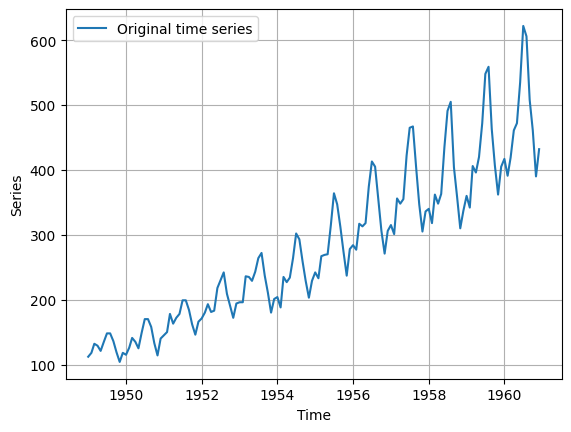

In [10]:
ts = TimeSeries(
    file_path='./data/AirPassengers.csv',
    series_col_name='Passengers',
    time_col_name='Month',
    time_format='%Y-%m'
)
ts.plot_series(label="Original time series")

## Smoothing

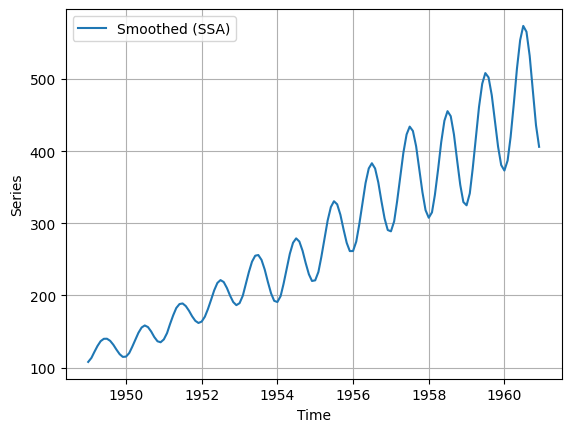

In [34]:
ssa = SSASmoother(window_length=12, components_to_keep=3)
smoothed = ssa.smooth(ts.series)
ts.plot_series(series=smoothed, label="Smoothed (SSA)")

## Wavelet decompose

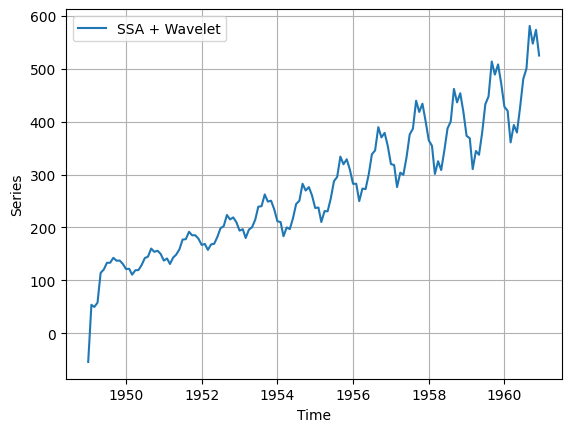

In [53]:
wavelet = WaveletDecomposer(level=2)
coeffs = wavelet.decompose(smoothed)
processed = wavelet.reconstruct(coeffs)
ts.plot_series(series=processed, label="SSA + Wavelet")